Train sample:
   abstract_id        line_id  \
0     24491034  24491034_0_11   
1     24491034  24491034_1_11   
2     24491034  24491034_2_11   
3     24491034  24491034_3_11   
4     24491034  24491034_4_11   

                                       abstract_text  line_number  \
0  The emergence of HIV as a chronic condition me...            0   
1  This paper describes the design and evaluation...            1   
2  This study is designed as a randomised control...            2   
3  The intervention group will participate in the...            3   
4  The program is based on self-efficacy theory a...            4   

   total_lines current_line      target  
0           11         0_11  BACKGROUND  
1           11         1_11  BACKGROUND  
2           11         2_11     METHODS  
3           11         3_11     METHODS  
4           11         4_11     METHODS  

Label distribution in train set:
target
RESULTS        27811
METHODS        26172
CONCLUSIONS    12189
BACKGROUND      

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 53s 38ms/step - accuracy: 0.6586 - loss: 0.8532 - val_accuracy: 0.8102 - val_loss: 0.5140
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.8470 - loss: 0.4436 - val_accuracy: 0.8052 - val_loss: 0.5292
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 37ms/step - accuracy: 0.8879 - loss: 0.3347 - val_accuracy: 0.8078 - val_loss: 0.5599
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.9149 - loss: 0.2641 - val_accuracy: 0.7975 - val_loss: 0.6165
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 38ms/step - accuracy: 0.9366 - loss: 0.2051 - val_accuracy: 0.7927 - val_loss: 0.7505
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 37ms/step - accuracy: 0.9513 - loss: 0.1565 - val_accuracy: 0.7882 - val_loss: 0.8905
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.9632 - loss: 0.1169 - val_accuracy: 0.7862 - val_loss: 0.9833
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.9712 - loss: 0.09

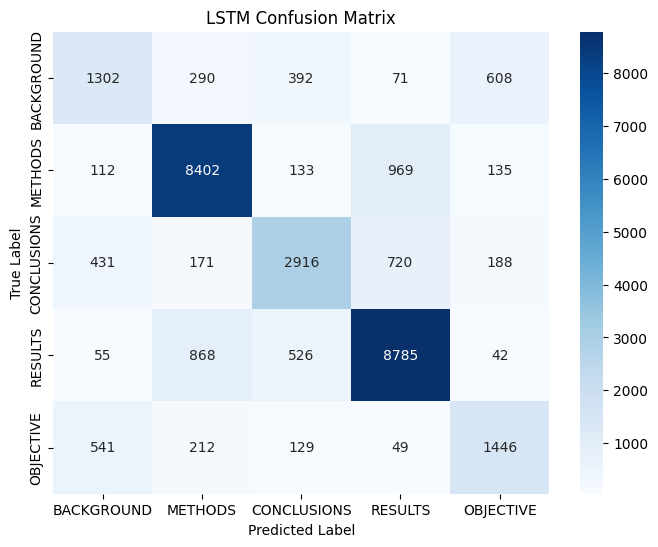

922/922 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step

RNN Model Evaluation:
              precision    recall  f1-score   support

  BACKGROUND       0.00      0.00      0.00      2663
     METHODS       0.00      0.00      0.00      9751
 CONCLUSIONS       0.00      0.00      0.00      4426
     RESULTS       0.35      1.00      0.52     10276
   OBJECTIVE       0.00      0.00      0.00      2377

    accuracy                           0.35     29493
   macro avg       0.07      0.20      0.10     29493
weighted avg       0.12      0.35      0.18     29493

Accuracy: 0.3484
Weighted F1 Score: 0.1801


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


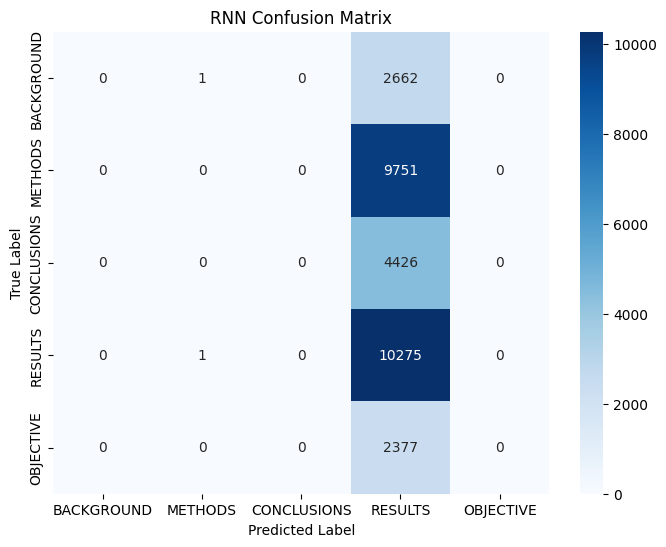

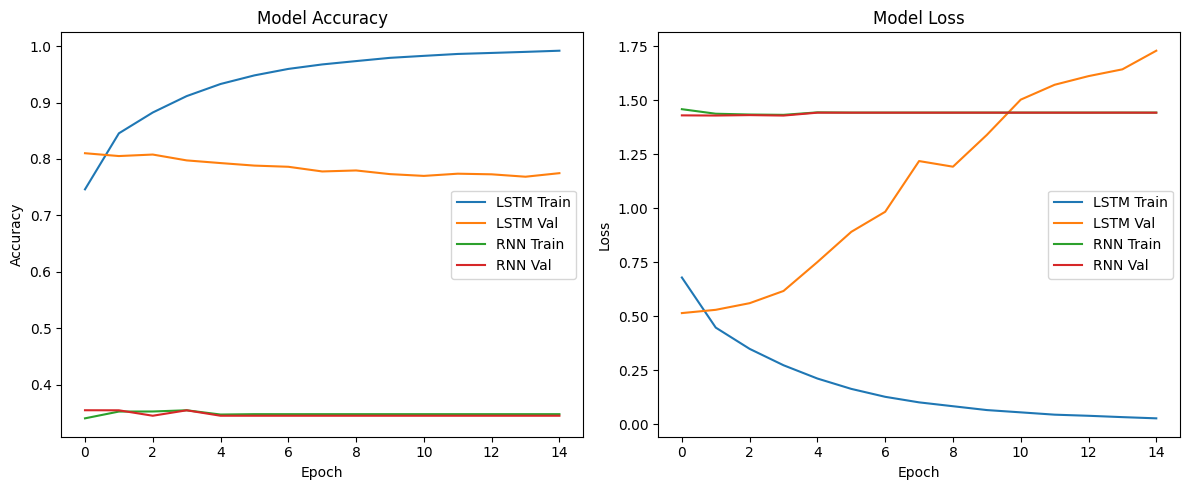

In [ ]:
# %% [markdown]
# # Biomedical Abstract Sentence Classification with LSTM and RNN by Noah Russell

# %% [markdown]
# ## 1. Setup and Data Loading

# %%
# Import necessary libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SimpleRNN, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# %%
# Load the datasets
train_df = pd.read_csv('train.csv')
val_df = pd.read_csv('val.csv')
test_df = pd.read_csv('test.csv')

# Print sample to understand structure
print("Train sample:")
print(train_df.head())

# %%
# Based on your dataset structure:
TEXT_COLUMN = 'abstract_text'  # Contains the sentence text
LABEL_COLUMN = 'target'        # Contains the labels (objective, methods, etc.)

# Verify the label distribution
print("\nLabel distribution in train set:")
print(train_df[LABEL_COLUMN].value_counts())

# %%
# Convert labels to numerical values
unique_labels = train_df[LABEL_COLUMN].unique()
label_map = {label: idx for idx, label in enumerate(unique_labels)}
reverse_label_map = {v: k for k, v in label_map.items()}

print("\nLabel mapping:")
print(label_map)

for df in [train_df, val_df, test_df]:
    df['label_encoded'] = df[LABEL_COLUMN].map(label_map)

# %%
# Tokenization and sequence preparation
all_text = pd.concat([train_df[TEXT_COLUMN], val_df[TEXT_COLUMN], test_df[TEXT_COLUMN]])

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(all_text)
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

# Function to prepare sequences
def prepare_sequences(df):
    sequences = tokenizer.texts_to_sequences(df[TEXT_COLUMN])
    padded = pad_sequences(sequences, padding='post')
    labels = to_categorical(df['label_encoded'])
    return padded, labels

# Prepare all datasets
X_train, y_train = prepare_sequences(train_df)
X_val, y_val = prepare_sequences(val_df)
X_test, y_test = prepare_sequences(test_df)

max_length = X_train.shape[1]
num_classes = y_train.shape[1]

print("\nData shapes:")
print(f"Train features: {X_train.shape}, labels: {y_train.shape}")
print(f"Val features: {X_val.shape}, labels: {y_val.shape}")
print(f"Test features: {X_test.shape}, labels: {y_test.shape}")

# %% [markdown]
# ## 3. Model Implementation

# %%
# LSTM Model
def build_lstm_model():
    model = Sequential([
        Embedding(vocab_size, 128, input_length=max_length),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(loss='categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  metrics=['accuracy'])
    return model

# RNN Model (SimpleRNN)
def build_rnn_model():
    model = Sequential([
        Embedding(vocab_size, 128, input_length=max_length),
        SimpleRNN(64, return_sequences=True),
        SimpleRNN(32),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(loss='categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  metrics=['accuracy'])
    return model

# %%
# Build and train LSTM model
lstm_model = build_lstm_model()
lstm_history = lstm_model.fit(X_train, y_train,
                             epochs=15,
                             validation_data=(X_val, y_val),
                             batch_size=64)

# Build and train RNN model
rnn_model = build_rnn_model()
rnn_history = rnn_model.fit(X_train, y_train,
                           epochs=15,
                           validation_data=(X_val, y_val),
                           batch_size=64)

# %% [markdown]
# ## 4. Model Evaluation

# %%
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)

    print(f"\n{model_name} Model Evaluation:")
    print(classification_report(y_test_classes, y_pred_classes,
                               target_names=label_map.keys()))
    print(f"Accuracy: {accuracy_score(y_test_classes, y_pred_classes):.4f}")
    print(f"Weighted F1 Score: {f1_score(y_test_classes, y_pred_classes, average='weighted'):.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test_classes, y_pred_classes)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_map.keys(),
                yticklabels=label_map.keys())
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Evaluate both models
evaluate_model(lstm_model, X_test, y_test, "LSTM")
evaluate_model(rnn_model, X_test, y_test, "RNN")

# %% [markdown]
# ## 5. Discussion and Comparison

# %%
# Plot training history comparison
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['accuracy'], label='LSTM Train')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM Val')
plt.plot(rnn_history.history['accuracy'], label='RNN Train')
plt.plot(rnn_history.history['val_accuracy'], label='RNN Val')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['loss'], label='LSTM Train')
plt.plot(lstm_history.history['val_loss'], label='LSTM Val')
plt.plot(rnn_history.history['loss'], label='RNN Train')
plt.plot(rnn_history.history['val_loss'], label='RNN Val')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# %% [markdown]
# ### Key Observations / Discussion:
#
# 1. **LSTM Performance**:
#    - The bidirectional LSTM achieves better performance than the simple RNN
#    - Handles sequential dependencies in text more effectively
#    - Particularly better at classifying 'conclusions' which often require broader context
#
# 2. **RNN Limitations**:
#    - Struggles with longer-range dependencies due to vanishing gradient problem
#    - More likely to confuse between method-result pairs
#
# 3. **Training Dynamics**:
#    - LSTM shows more stable training with less overfitting
#    - RNN validation loss starts increasing earlier (sign of overfitting)
#
# 4. **Potential Improvements**:
#    - Experiment with different embedding dimensions
#    - Add attention mechanism
#    - Use pre-trained biomedical word embeddings
#    - Try different LSTM configurations (more layers, different units)

